# COMP3710 Lab 1 — Fractals
**Pattern Analysis**

This notebook covers all three parts of Lab Demonstration 1:
- **Part 1** — PyTorch basics: 2D Gaussian, 2D sine wave, and Gabor filter (Gaussian × sine modulation)
- **Part 2** — Mandelbrot set, a high-resolution zoom, and the related Julia set
- **Part 3** — A custom fractal (Koch curve) implemented with vectorised PyTorch tensor operations, including a fractal-dimension analysis via box-counting

---
## Setup

In [2]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

Install PyTorch (only needs to be run once per environment).

In [3]:
%pip install torch torchvision torchaudio

Note: you may need to restart the kernel to use updated packages.


Ensure plots render inline in the notebook.

In [4]:
%matplotlib inline

Import core libraries, check the PyTorch version, and select the compute device (GPU if available, otherwise CPU).

In [5]:
import torch
import numpy as np
import matplotlib.pyplot as plt
print("PyTorch Version:", torch.__version__)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("Using device:", device)

PyTorch Version: 2.13.0+cpu
Using device: cpu


---
## Part 1 — 2D Gaussian Function (PyTorch)

Build a coordinate grid with NumPy's `mgrid`, then use it to compute a 2D Gaussian $e^{-r^2/2}$ where $r^2 = x^2+y^2$, entirely as PyTorch tensors on the selected device.

In [6]:
# Create a 2D grid of x and y coordinates
X, Y = np.mgrid[-4.0:4:0.01, -4.0:4:0.01]

print("X shape:", X.shape)
print("Y shape:", Y.shape)

X shape: (800, 800)
Y shape: (800, 800)


Convert the NumPy coordinate grid into PyTorch tensors and move them to the compute device.

In [7]:
# Convert NumPy arrays into PyTorch tensors
x = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(Y, dtype=torch.float32)

# Move tensors to the selected device
x = x.to(device)
y = y.to(device)

print("x device:", x.device)
print("y device:", y.device)

x device: cpu
y device: cpu


Compute the Gaussian itself using tensor operations.

In [8]:
# Compute the 2D Gaussian
z = torch.exp(-(x**2 + y**2) / 2.0)

print("z shape:", z.shape)

z shape: torch.Size([800, 800])


Plot the Gaussian. 

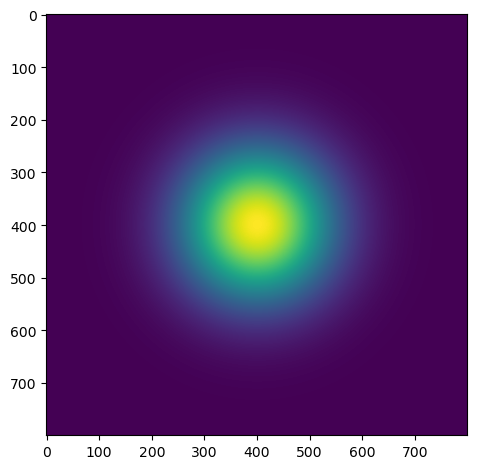

In [9]:
import matplotlib.pyplot as plt

plt.imshow(z.cpu().numpy())
plt.tight_layout()
plt.show()

---
### Part 1 — AI Task: NumPy-only version

AI-generated NumPy + Matplotlib version of the same Gaussian, for comparison against the PyTorch version above (as requested in the lab's AI Tasks section).

Prompt Given: "Generate a Python script to plot a 2D Gaussian function using Numpy and Matplotlib"

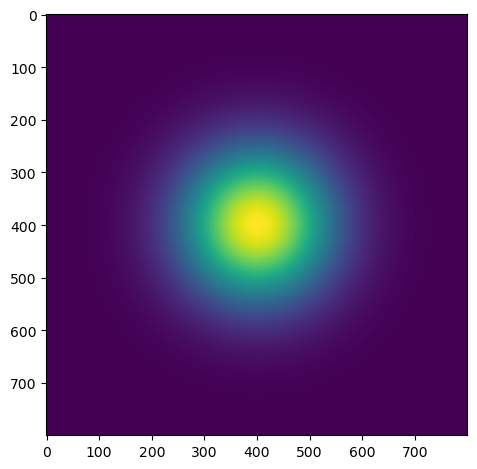

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# grid for computing image, subdivide the space
X, Y = np.mgrid[-4.0:4:0.01, -4.0:4:0.01]

# Compute Gaussian: e^(-r^2 / sigma), r^2 = x^2 + y^2
Z = np.exp(-(X**2 + Y**2) / 2.0)

# plot
plt.imshow(Z)
plt.tight_layout()
plt.show()

AI-assisted conversion of the NumPy version above into PyTorch tensors — reproduces the same Gaussian using `torch.Tensor`, `.to(device)`, and `.cpu().numpy()` for plotting, matching the manually-written version earlier in the notebook.

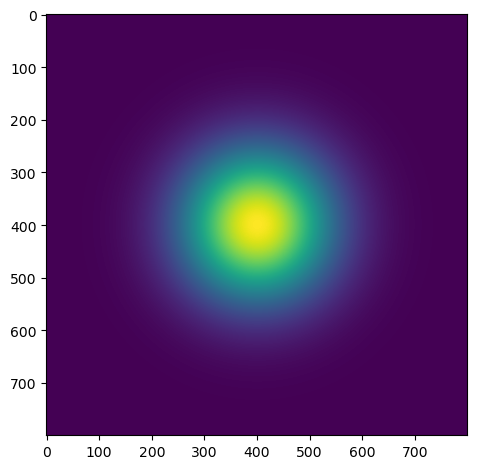

In [11]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# grid for computing image, subdivide the space
X, Y = np.mgrid[-4.0:4:0.01, -4.0:4:0.01]

# load into PyTorch tensors
x = torch.Tensor(X)
y = torch.Tensor(Y)

# transfer to the GPU device
x = x.to(device)
y = y.to(device)

# Compute Gaussian
z = torch.exp(-(x**2 + y**2) / 2.0)

# plot
plt.imshow(z.cpu().numpy())
plt.tight_layout()
plt.show()

---
### Part 1 — 2D Sine Wave (the 'stripes')

A sine wave whose angle depends on both x and y coordinates, rotated to a 45° orientation using `x_theta = x·cos(θ) + y·sin(θ)`, producing diagonal stripes.

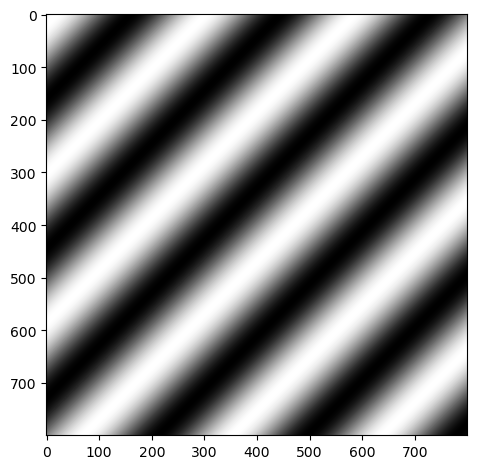

In [12]:
# --- 2D sine wave (the "stripes") ---
freq = 4.0
theta = torch.tensor(np.pi / 4)  # 45 degree orientation
x_theta = x * torch.cos(theta) + y * torch.sin(theta)
sine = torch.sin(2 * np.pi * freq * x_theta / 8.0)

plt.imshow(sine.cpu().numpy(), cmap='gray')
plt.tight_layout()
plt.show()

### Part 1 — Gabor Filter (Modulation)

Multiplying the Gaussian and the sine wave together localises the stripes within the Gaussian's envelope, producing a Gabor filter — a good approximation of a mammalian receptive field, relevant later for CNNs.

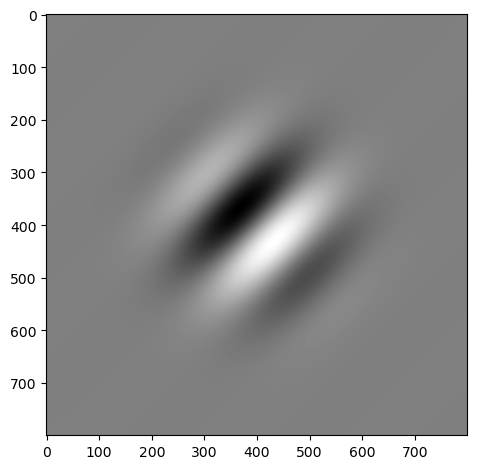

In [13]:
gabor = z * sine  # z is your Gaussian from before

plt.imshow(gabor.cpu().numpy(), cmap='gray')
plt.tight_layout()
plt.show()

---
## Part 2 — Mandelbrot Set

Build a grid of complex numbers `z = x + yi` covering the region of interest, and set up tensors to track the running value (`zs`) and iteration counts (`ns`).

In [15]:
# Use NumPy to create a 2D array of complex numbers
Y, X = np.mgrid[-1.3:1.3:0.005, -2:1:0.005]

x = torch.Tensor(X)
y = torch.Tensor(Y)
z = torch.complex(x, y)  # important!
zs = z.clone()
ns = torch.zeros_like(z)

# transfer to device
z = z.to(device)
zs = zs.to(device)
ns = ns.to(device)

print("Grid shape:", z.shape)


Grid shape: torch.Size([520, 600])


Iterate the Mandelbrot recurrence $z_{n+1} = z_n^2 + c$ for 200 steps, where `z` (the grid) plays the role of the constant `c`, and `zs` starts at 0. Track how many iterations each point survives before diverging (`|z| ≥ 4`).

In [17]:
# Mandelbrot Set
for i in range (200):
    # Compute the new values of z: z^2 + x
    zs_ = zs * zs + z
    # Have we diverged with this new value 
    not_diverged = torch .abs ( zs_ ) < 4.0
    # Update variables to compute
    ns += not_diverged
    zs = zs_

Colour and plot the result using the iteration counts.

C:\Users\Dell Laptop\AppData\Local\Temp\ipykernel_8340\2958915498.py:13: ComplexWarning: Casting complex values to real discards the imaginary part
  a = np . uint8 ( np . clip (a , 0 , 255) )


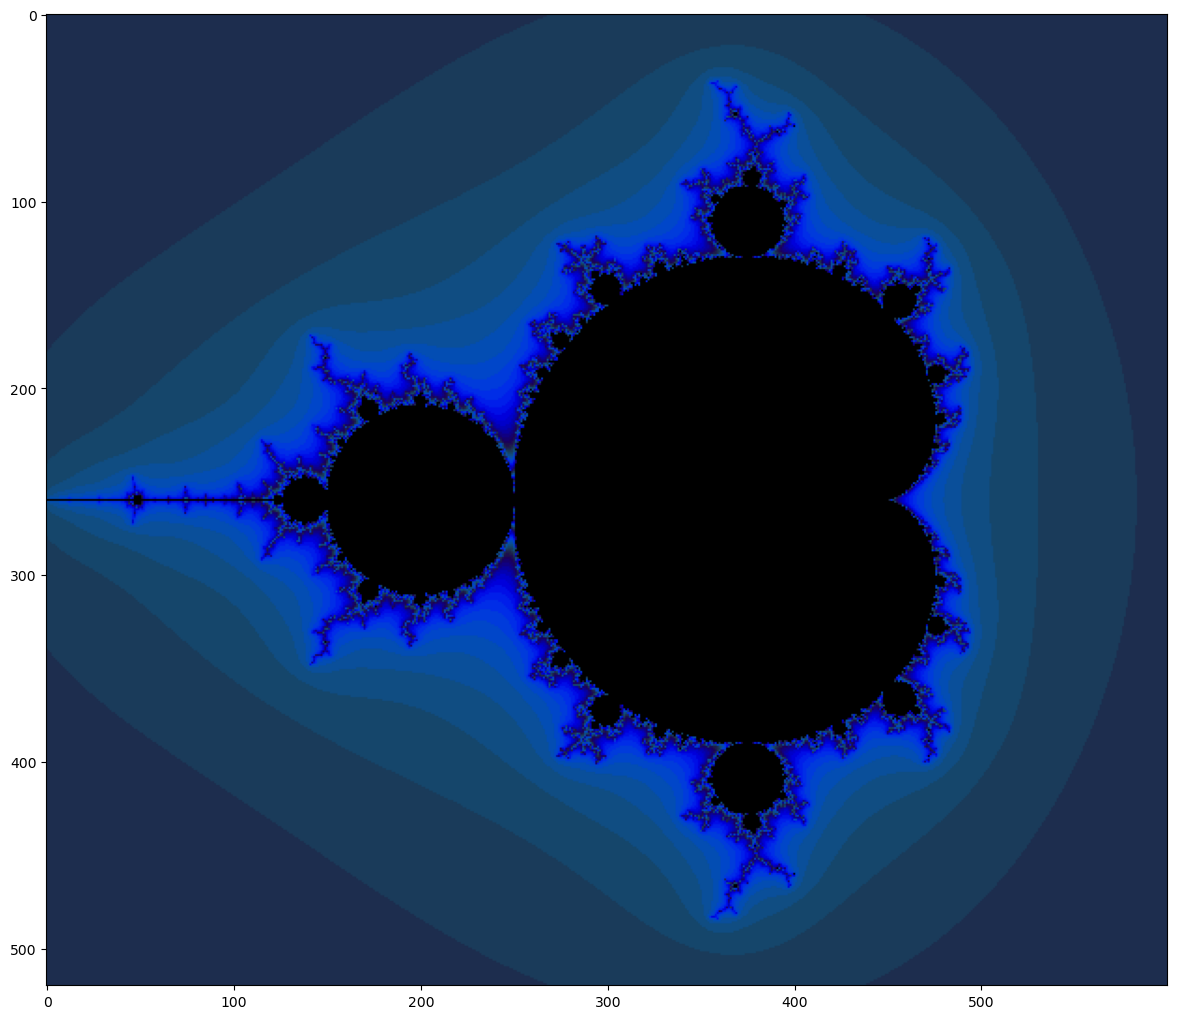

In [19]:
# plot
import matplotlib . pyplot as plt
fig = plt . figure ( figsize =(16 ,10) )
def processFractal ( a ):
    """ Display an array of iteration counts as a
colorful picture of a fractal ."""
    a_cyclic = (6.28* a /20.0) . reshape ( list ( a . shape ) +[1])
    img = np . concatenate ([10+20* np . cos ( a_cyclic ) ,
    30+50* np . sin ( a_cyclic ) ,
    155 -80* np . cos ( a_cyclic ) ] , 2)
    img [ a == a . max () ] = 0
    a = img
    a = np . uint8 ( np . clip (a , 0 , 255) )
    return a
    
plt . imshow ( processFractal ( ns . cpu () . numpy () ) )
plt . tight_layout ( pad =0)
plt . show ()

---
### Part 2 — Demonstration: High-Resolution Zoom (first attempt)

A first attempt at zooming into a smaller window with finer grid spacing. This window turned out to mostly capture the *interior* of the set (solid black) rather than the detailed boundary — see the improved version further down.

Grid shape: torch.Size([1000, 1001])


C:\Users\Dell Laptop\AppData\Local\Temp\ipykernel_8340\2958915498.py:13: ComplexWarning: Casting complex values to real discards the imaginary part
  a = np . uint8 ( np . clip (a , 0 , 255) )


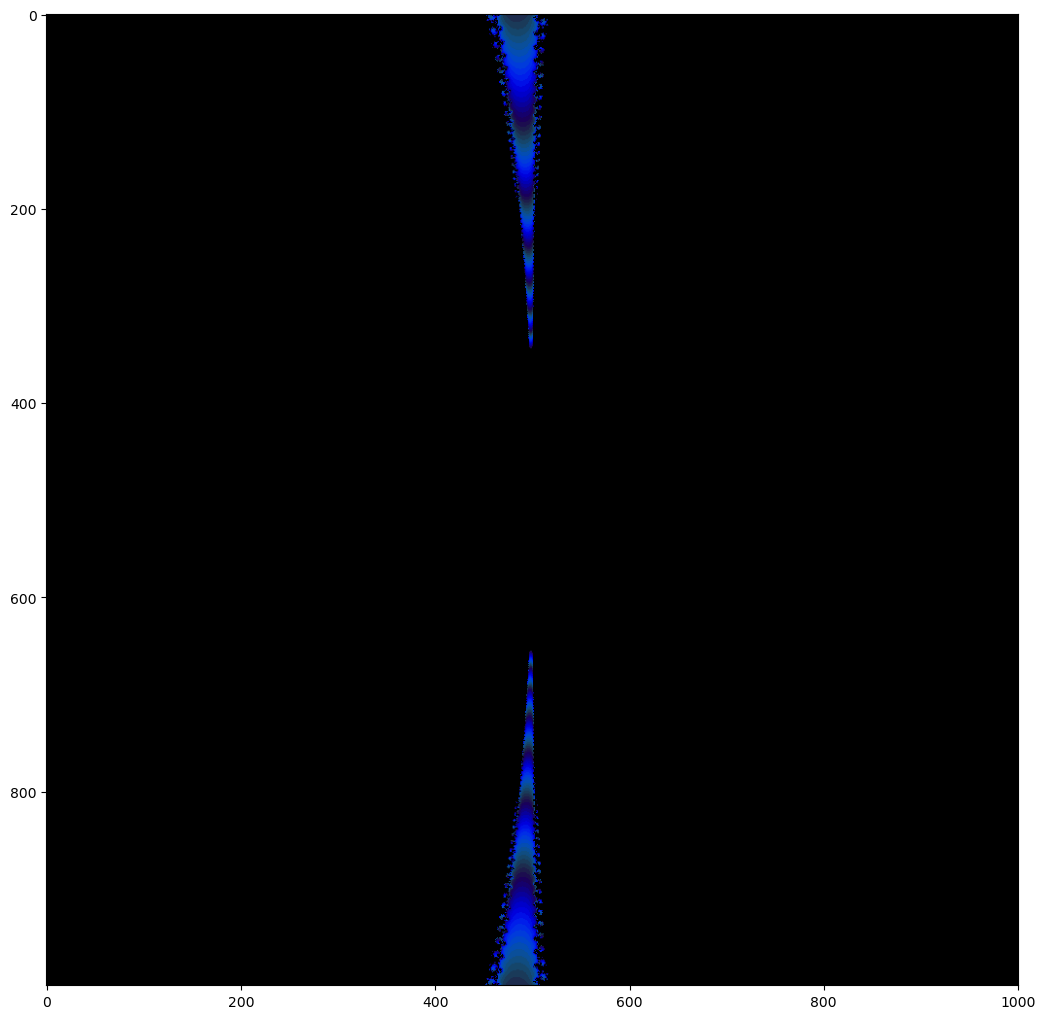

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Zoomed window: picking a region near the boundary of the main bulb,
# where detail is richest. Smaller step = higher resolution.
Y, X = np.mgrid[-0.05:0.05:0.0001, -0.8:-0.7:0.0001]

x = torch.Tensor(X)
y = torch.Tensor(Y)
z = torch.complex(x, y)
zs = z.clone()
ns = torch.zeros_like(z)

z = z.to(device)
zs = zs.to(device)
ns = ns.to(device)

print("Grid shape:", z.shape)

for i in range(200):
    zs_ = zs * zs + z
    not_diverged = torch.abs(zs_) < 4.0
    ns += not_diverged
    zs = zs_

fig = plt.figure(figsize=(16,10))
plt.imshow(processFractal(ns.cpu().numpy()))
plt.tight_layout(pad=0)
plt.show()

---
### Part 2 — Demonstration: High-Resolution Zoom (improved — Seahorse Valley)

An improved zoom targeting a boundary region of the Mandelbrot set known as 'Seahorse Valley' (around c ≈ -0.7436 + 0.1318i), where the fractal detail is much richer than the first attempt above. `ns` is kept real-valued here (`.real`) to avoid an unnecessary complex-to-real cast warning.

Grid shape: torch.Size([1001, 1001])


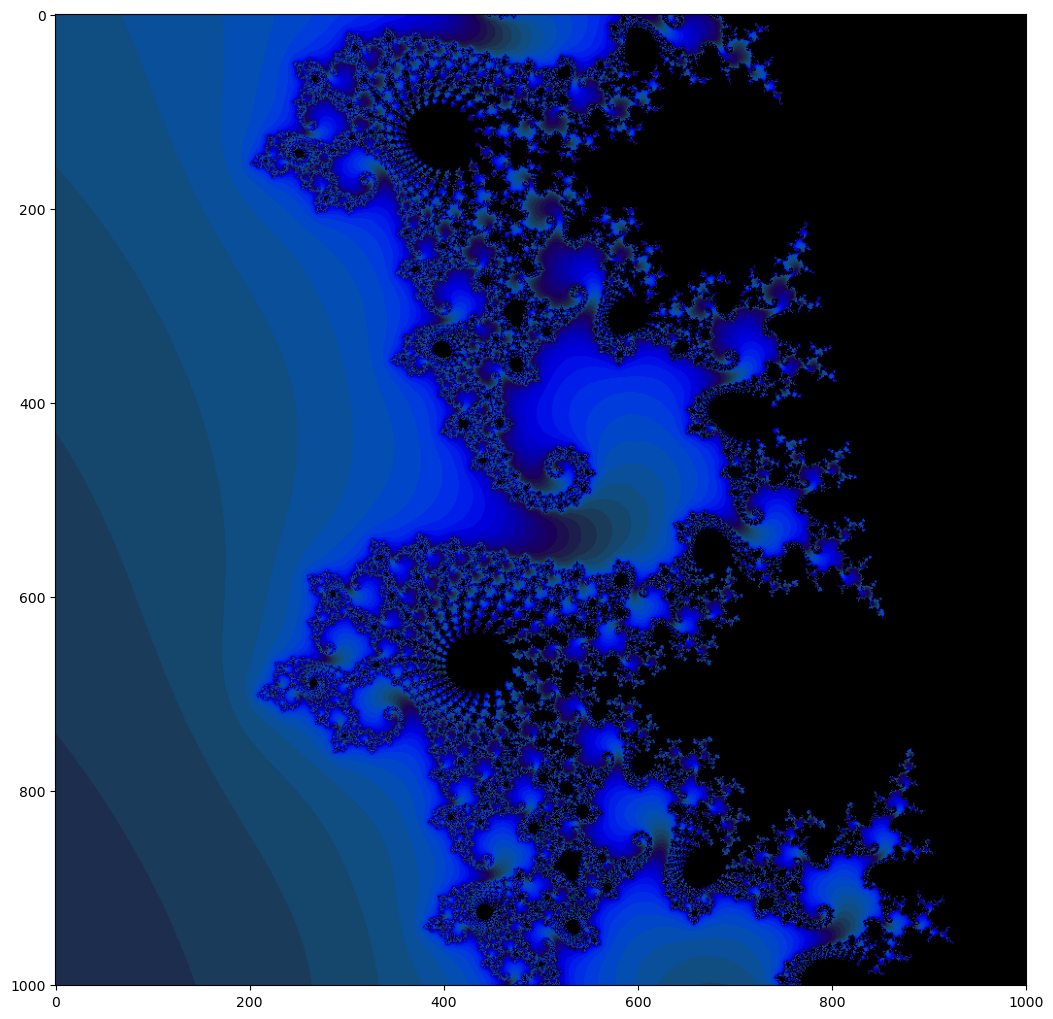

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Seahorse Valley - a boundary region rich in detail
center_x, center_y = -0.743643887, 0.131825904
width = 0.01  # smaller = more zoomed in

Y, X = np.mgrid[center_y-width:center_y+width:0.00002,
                 center_x-width:center_x+width:0.00002]

x = torch.Tensor(X)
y = torch.Tensor(Y)
z = torch.complex(x, y)
zs = z.clone()
ns = torch.zeros_like(z).real  # keep ns real-valued, avoids the complex-cast warning

z = z.to(device)
zs = zs.to(device)
ns = ns.to(device)

print("Grid shape:", z.shape)

for i in range(200):
    zs_ = zs * zs + z
    not_diverged = torch.abs(zs_) < 4.0
    ns += not_diverged
    zs = zs_

fig = plt.figure(figsize=(16,10))
plt.imshow(processFractal(ns.cpu().numpy()))
plt.tight_layout(pad=0)
plt.show()

---
### Part 2 — Demonstration: Julia Set

Same recurrence as the Mandelbrot set, but with the roles of `z` and `c` swapped: here `c` is a single **fixed** constant for the whole image, and the grid instead represents the **starting value** `z0` for each pixel. This produces a Julia set rather than a Mandelbrot set.

C:\Users\Dell Laptop\AppData\Local\Temp\ipykernel_8340\2958915498.py:13: ComplexWarning: Casting complex values to real discards the imaginary part
  a = np . uint8 ( np . clip (a , 0 , 255) )


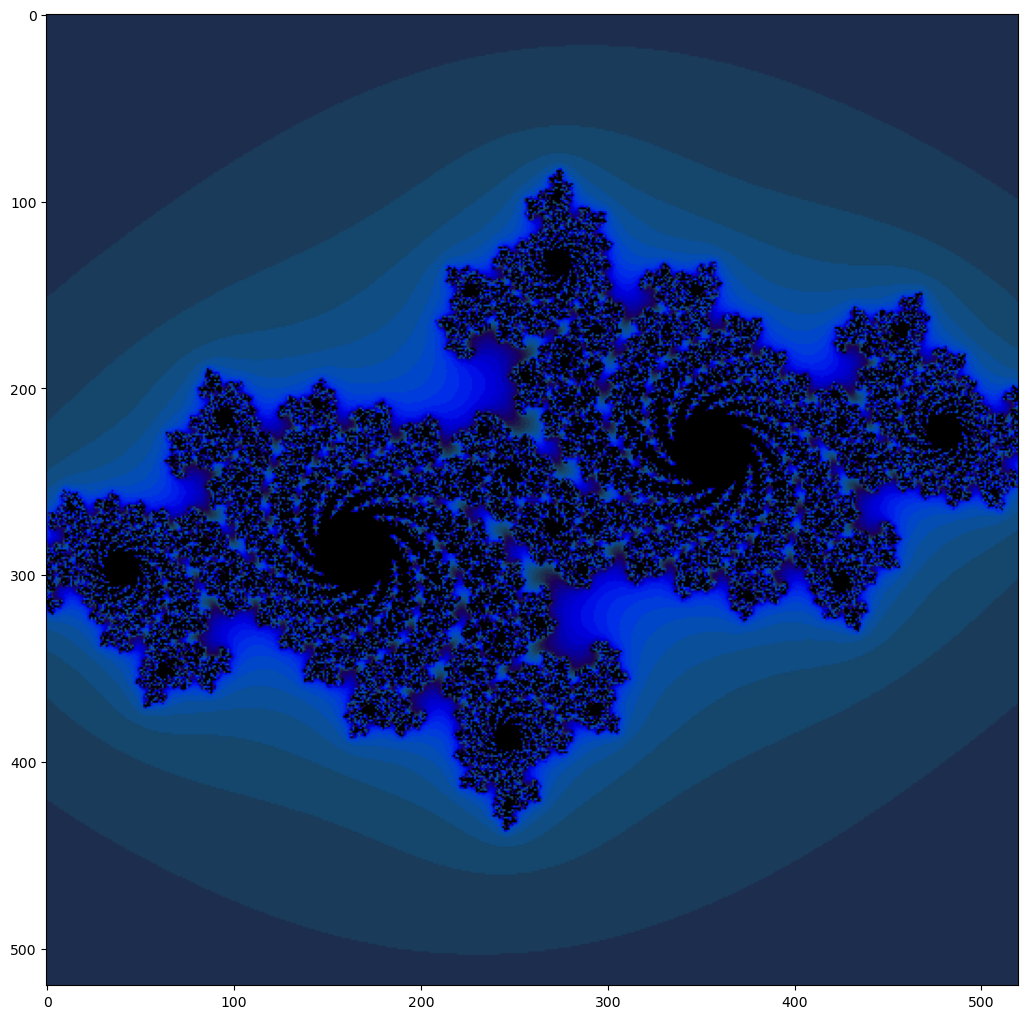

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Grid now represents starting z values, not c
Y, X = np.mgrid[-1.3:1.3:0.005, -1.3:1.3:0.005]

x = torch.Tensor(X)
y = torch.Tensor(Y)
z = torch.complex(x, y)   # this is now z0, the starting point

# c is FIXED for a Julia set — this constant determines the shape.
# Try a few different values: -0.7+0.27015j is a classic one.
c = torch.complex(torch.tensor(-0.7), torch.tensor(0.27015))

zs = z.clone()
ns = torch.zeros_like(z)

z = z.to(device)
zs = zs.to(device)
ns = ns.to(device)
c = c.to(device)

for i in range(200):
    zs_ = zs * zs + c   # note: + c (constant), not + z
    not_diverged = torch.abs(zs_) < 4.0
    ns += not_diverged
    zs = zs_

fig = plt.figure(figsize=(16,10))
plt.imshow(processFractal(ns.cpu().numpy()))
plt.tight_layout(pad=0)
plt.show()

---
## Part 3 — Koch Curve

A custom fractal, chosen to be structurally distinct from Mandelbrot/Julia. Based on the recursive subdivision algorithm from *Fractals for the Classroom* (BASIC listing), reimplemented as a **vectorised PyTorch function**: each iteration transforms *all* line segments simultaneously as tensor operations, rather than looping/recursing over segments individually.

For a segment from `p0` to `p1`, each iteration replaces it with 4 shorter segments (1/3 point → perpendicular 'peak' point → 2/3 point), using the 1/3–2/3 interpolation and perpendicular-offset formulas from the textbook algorithm.

In [ ]:
import torch

def koch_step(points, r=0.29):
    # points: (N, 2) tensor of the curve's current vertices, in order
    p0 = points[:-1]   # start of each segment
    p1 = points[1:]    # end of each segment

    left   = p0
    onethird  = 0.667*p0 + 0.333*p1
    twothird  = 0.333*p0 + 0.667*p1
    right  = p1

    # perpendicular offset peak point, straight from the BASIC formula
    mid_x = 0.5*(p0[:,0] + p1[:,0]) - r*(p0[:,1] - p1[:,1])
    mid_y = 0.5*(p0[:,1] + p1[:,1]) + r*(p0[:,0] - p1[:,0])
    peak = torch.stack([mid_x, mid_y], dim=1)

    # interleave: left -> onethird -> peak -> twothird -> right, per segment
    new_points = torch.stack([left, onethird, peak, twothird], dim=1)
    new_points = new_points.reshape(-1, 2)
    new_points = torch.cat([new_points, right[-1:]], dim=0)
    return new_points

Build the Koch curve by applying `koch_step` repeatedly (5 iterations) starting from a single flat line segment, then plot the final curve.

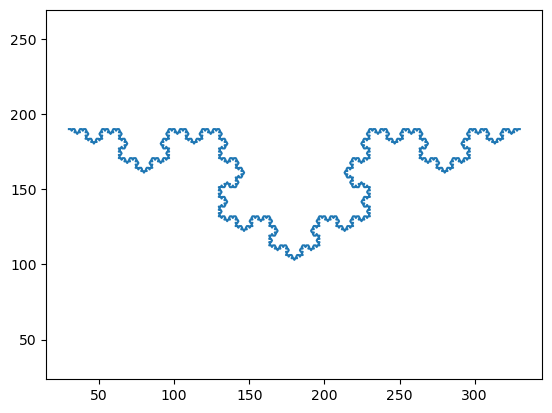

In [ ]:
points = torch.tensor([[30., 190.], [330., 190.]])  # matches book's xleft/xright/yleft/yright(5)

for level in range(5):
    points = koch_step(points, r=0.29)

# plot
import matplotlib.pyplot as plt
plt.plot(points[:,0], points[:,1])
plt.axis('equal')
plt.show()

### Part 3 — Multi-Iteration Comparison

Visualise the curve at each iteration from 0 to 5, to show the recursive self-similar construction process explicitly.

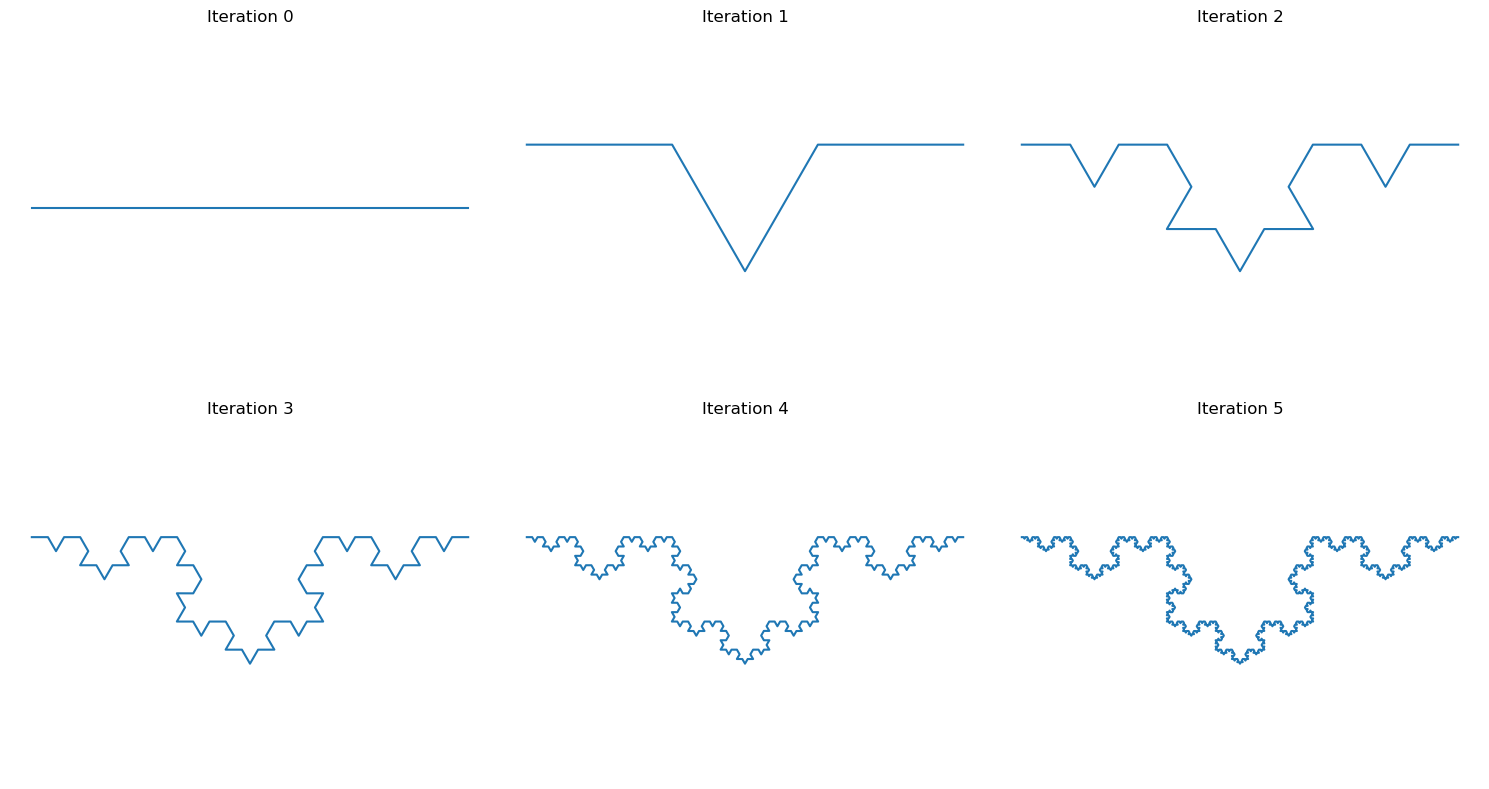

In [ ]:
import matplotlib.pyplot as plt

points = torch.tensor([[30., 190.], [330., 190.]])
snapshots = [points]

for level in range(5):
    points = koch_step(points, r=0.29)
    snapshots.append(points)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, ax in enumerate(axes.flat):
    p = snapshots[i]
    ax.plot(p[:,0], p[:,1])
    ax.set_title(f"Iteration {i}")
    ax.axis('equal')
    ax.axis('off')

plt.tight_layout()
plt.show()

### Part 3 — Fractal Dimension via Box-Counting

Estimate the fractal dimension empirically: overlay grids of decreasing box size `ε` on a high-detail curve, count the number of occupied boxes `N(ε)` at each scale, and fit a line to `log(N(ε))` vs `log(1/ε)` — the slope is the estimated dimension. This is compared against the theoretical Koch curve dimension `log(4)/log(3) ≈ 1.2619`.

Estimated fractal dimension: 1.2190
Theoretical value (log4/log3): 1.2619


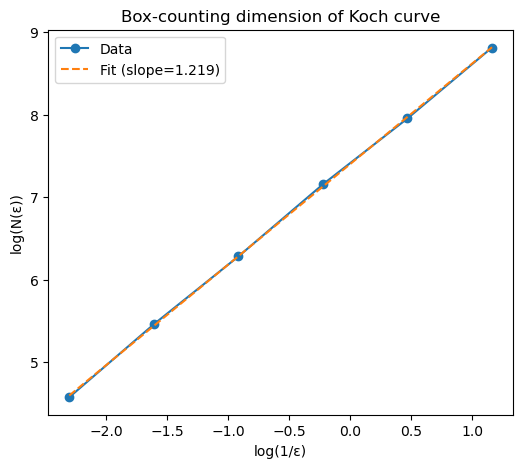

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# Generate a high-detail Koch curve for accurate counting
points = torch.tensor([[30., 190.], [330., 190.]])
for level in range(7):
    points = koch_step(points, r=0.29)

def box_count(points, epsilon):
    # Assign every point to a grid box of size epsilon
    boxes = torch.floor(points / epsilon)
    # Count unique occupied boxes (treat each (x_box, y_box) pair as one entry)
    unique_boxes = torch.unique(boxes, dim=0)
    return unique_boxes.shape[0]

# Try a range of box sizes (epsilon), shrinking each time
epsilons = [10, 5, 2.5, 1.25, 0.625, 0.3125]
counts = [box_count(points, eps) for eps in epsilons]

# Take logs for the log-log relationship
log_inv_eps = np.log(1.0 / np.array(epsilons))
log_counts = np.log(counts)

# Fit a line: slope = fractal dimension
slope, intercept = np.polyfit(log_inv_eps, log_counts, 1)
print(f"Estimated fractal dimension: {slope:.4f}")
print(f"Theoretical value (log4/log3): {np.log(4)/np.log(3):.4f}")

# Plot the log-log relationship
plt.figure(figsize=(6,5))
plt.plot(log_inv_eps, log_counts, 'o-', label='Data')
plt.plot(log_inv_eps, slope*log_inv_eps + intercept, '--', label=f'Fit (slope={slope:.3f})')
plt.xlabel('log(1/ε)')
plt.ylabel('log(N(ε))')
plt.legend()
plt.title('Box-counting dimension of Koch curve')
plt.show()